Imagen guardada en: star_like_curve_with_cusps.png
GIF guardado en: star_like_curve_with_cusps.gif


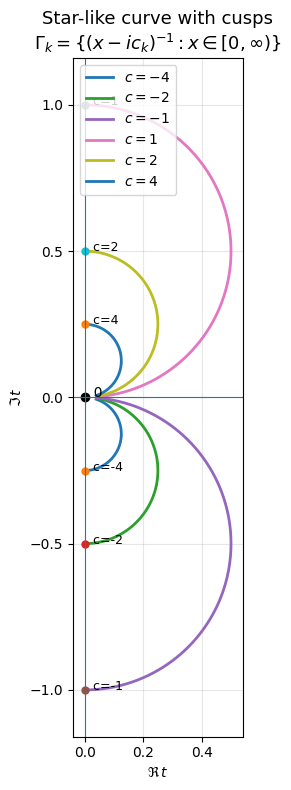

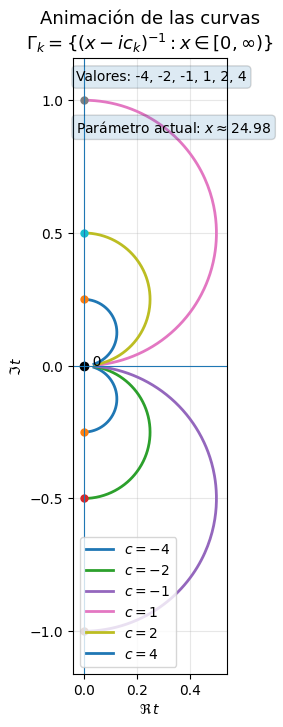

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ============================================================
# Parámetros
# ============================================================
# Cambia aquí tus valores c1 < c2 < ... < cn, todos distintos de 0
c_values = [-4, -2, -1, 1, 2, 4]

# Rango del parámetro x en t = 1 / (x - i c)
x_max = 25
num_points = 1200
x = np.linspace(0, x_max, num_points)

# Archivos de salida
gif_filename = "star_like_curve_with_cusps.gif"
png_filename = "star_like_curve_with_cusps.png"

# ============================================================
# Definición de la curva Gamma_c
# ============================================================
def gamma_curve(x, c):
    """
    Retorna t(x) = 1 / (x - i c), separando parte real e imaginaria.
    """
    t = 1.0 / (x - 1j * c)
    return np.real(t), np.imag(t)

# Precalcular curvas
curves = []
for c in c_values:
    xr, yi = gamma_curve(x, c)
    curves.append((c, xr, yi))

# ============================================================
# Gráfico estático
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

for c, xr, yi in curves:
    ax.plot(xr, yi, linewidth=2, label=fr"$c={c}$")

    # Punto inicial x=0  ->  t(0)=1/(-ic)=i/c
    x0, y0 = xr[0], yi[0]
    ax.plot(x0, y0, 'o', markersize=5)
    ax.text(x0, y0, f"  c={c}", fontsize=9)

# Marcar el origen, punto común hacia donde se orientan las curvas
ax.plot(0, 0, 'ko', markersize=6)
ax.text(0, 0, "  0", fontsize=10)

ax.set_title("Star-like curve with cusps\n" + r"$\Gamma_k=\{(x-i c_k)^{-1}: x\in[0,\infty)\}$", fontsize=13)
ax.set_xlabel(r"$\Re\, t$")
ax.set_ylabel(r"$\Im\, t$")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# Ajuste automático de límites
all_x = np.concatenate([xr for _, xr, _ in curves])
all_y = np.concatenate([yi for _, _, yi in curves])
pad_x = 0.08 * (all_x.max() - all_x.min() + 1e-8)
pad_y = 0.08 * (all_y.max() - all_y.min() + 1e-8)

ax.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

plt.tight_layout()
plt.savefig(png_filename, dpi=200)
print(f"Imagen guardada en: {png_filename}")

# ============================================================
# Animación GIF
# ============================================================
fig2, ax2 = plt.subplots(figsize=(8, 8))

lines = []
start_points = []
for c, xr, yi in curves:
    line, = ax2.plot([], [], linewidth=2, label=fr"$c={c}$")
    point, = ax2.plot([], [], 'o', markersize=5)
    lines.append((line, xr, yi, c))
    start_points.append(point)

ax2.plot(0, 0, 'ko', markersize=6)
ax2.text(0, 0, "  0", fontsize=10)

ax2.set_title("Animación de las curvas\n" + r"$\Gamma_k=\{(x-i c_k)^{-1}: x\in[0,\infty)\}$", fontsize=13)
ax2.set_xlabel(r"$\Re\, t$")
ax2.set_ylabel(r"$\Im\, t$")
ax2.axhline(0, linewidth=0.8)
ax2.axvline(0, linewidth=0.8)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')
ax2.legend()
ax2.set_xlim(all_x.min() - pad_x, all_x.max() + pad_x)
ax2.set_ylim(all_y.min() - pad_y, all_y.max() + pad_y)

# Texto con la lista de valores c_k
c_text = ", ".join(str(c) for c in c_values)
info_text = ax2.text(
    0.02, 0.98,
    f"Valores: {c_text}",
    transform=ax2.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

frame_text = ax2.text(
    0.02, 0.90,
    "",
    transform=ax2.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

def init():
    for (line, xr, yi, c), point in zip(lines, start_points):
        line.set_data([], [])
        point.set_data([xr[0]], [yi[0]])
    frame_text.set_text("")
    return [line for line, _, _, _ in lines] + start_points + [frame_text]

def update(frame):
    # frame recorre los puntos de 1 hasta num_points
    idx = max(2, frame)

    for (line, xr, yi, c), point in zip(lines, start_points):
        line.set_data(xr[:idx], yi[:idx])
        point.set_data([xr[0]], [yi[0]])

    current_x = x[min(idx - 1, len(x) - 1)]
    frame_text.set_text(fr"Parámetro actual: $x \approx {current_x:.2f}$")

    return [line for line, _, _, _ in lines] + start_points + [frame_text]

anim = FuncAnimation(
    fig2,
    update,
    frames=num_points,
    init_func=init,
    interval=20,
    blit=False
)

writer = PillowWriter(fps=30)
anim.save(gif_filename, writer=writer)
print(f"GIF guardado en: {gif_filename}")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Output paths
gif_path = "slowly_oscillating_composed_curve.gif"
py_path = "slowly_oscillating_composed_curve_example.py"

# ----------------------------
# Example geometry
# Nodes: 0, 2, infinity
# ----------------------------

# Arc 1: bounded smooth arc from 0 to 2
s1 = np.linspace(0, 1, 500)
x1 = 2*s1
y1 = 0.18*np.sin(np.pi*s1)*(1 - 0.35*np.cos(2*np.pi*s1))

# Arcs 2 and 3: unbounded arcs from 0 to infinity, star-like with mild oscillation
r = np.linspace(0.01, 6.0, 800)

def theta_up(rr):
    return 0.95 + 0.18*np.exp(-0.22*rr)*np.sin(2.2*np.log1p(rr))

def theta_down(rr):
    return -0.95 + 0.16*np.exp(-0.20*rr)*np.sin(2.0*np.log1p(rr) + 0.6)

th2 = theta_up(r)
th3 = theta_down(r)

x2 = r*np.cos(th2)
y2 = r*np.sin(th2)

x3 = r*np.cos(th3)
y3 = r*np.sin(th3)

# Local disks for visualization near finite nodes
theta = np.linspace(0, 2*np.pi, 240)
eps0 = 0.55
eps2 = 0.35
disk0_x = eps0*np.cos(theta)
disk0_y = eps0*np.sin(theta)
disk2_x = 2 + eps2*np.cos(theta)
disk2_y = eps2*np.sin(theta)

# Figure
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-0.9, 4.7)
ax.set_ylim(-4.2, 4.2)
ax.grid(True, alpha=0.25)
ax.set_title("Ejemplo ilustrativo: slowly oscillating composed curve")
ax.set_xlabel(r"$\Re z$")
ax.set_ylabel(r"$\Im z$")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

# Static guides
ax.plot(disk0_x, disk0_y, "--", linewidth=1, alpha=0.55, label=r"$D(0,\varepsilon)$")
ax.plot(disk2_x, disk2_y, "--", linewidth=1, alpha=0.55, label=r"$D(2,\varepsilon)$")
ax.plot(0, 0, "ko", markersize=7)
ax.text(0.05, 0.08, r"$t_0=0$", fontsize=11)
ax.plot(2, 0, "ko", markersize=7)
ax.text(2.05, 0.08, r"$t_1=2$", fontsize=11)
ax.text(4.15, 0.15, r"$\infty$", fontsize=14)

# Animated lines
line1, = ax.plot([], [], linewidth=2.6, label=r"$\Gamma_1$: bounded arc $0\to 2$")
line2, = ax.plot([], [], linewidth=2.6, label=r"$\Gamma_2$: unbounded arc $0\to\infty$")
line3, = ax.plot([], [], linewidth=2.6, label=r"$\Gamma_3$: unbounded arc $0\to\infty$")

# Orientation markers
head1, = ax.plot([], [], "o", markersize=6)
head2, = ax.plot([], [], "o", markersize=6)
head3, = ax.plot([], [], "o", markersize=6)

# Explanatory text
textbox = ax.text(
    0.02, 0.98, "",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.12)
)

ax.legend(loc="lower left", fontsize=9)

n1, n2, n3 = len(x1), len(x2), len(x3)
frames = max(n1, n2, n3)

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    head1.set_data([], [])
    head2.set_data([], [])
    head3.set_data([], [])
    textbox.set_text("")
    return line1, line2, line3, head1, head2, head3, textbox

def update(frame):
    i1 = min(frame, n1 - 1)
    i2 = min(frame, n2 - 1)
    i3 = min(frame, n3 - 1)

    line1.set_data(x1[:i1+1], y1[:i1+1])
    line2.set_data(x2[:i2+1], y2[:i2+1])
    line3.set_data(x3[:i3+1], y3[:i3+1])

    head1.set_data([x1[i1]], [y1[i1]])
    head2.set_data([x2[i2]], [y2[i2]])
    head3.set_data([x3[i3]], [y3[i3]])

    if frame < frames//3:
        msg = (
            "Nodo finito t0=0: localmente se ven varias ramas\n"
            "con estructura star-like dentro de D(0, ε)."
        )
    elif frame < 2*frames//3:
        msg = (
            "Γ1 es un arco acotado con extremos 0 y 2.\n"
            "Γ2 y Γ3 son arcos no acotados con extremo en ∞."
        )
    else:
        msg = (
            "La curva compuesta es Γ = Γ1 ∪ Γ2 ∪ Γ3.\n"
            "Las ramas tienen interiores disjuntos y no forman cúspides en 0 ni en 2."
        )
    textbox.set_text(msg)

    return line1, line2, line3, head1, head2, head3, textbox

anim = FuncAnimation(fig, update, frames=frames, init_func=init, interval=18, blit=False)
anim.save(gif_path, writer=PillowWriter(fps=28))
plt.close(fig)

